#  Sleep Disorder Prediction System

##  Problem
Sleep disorders, such as **sleep apnea** and **insomnia**, are often hard to detect and can have **negative effects on health and overall well-being**.  
Early detection is crucial for preventing long-term health issues and improving quality of life.

##  Goal
The goal of this project is to build a **machine learning classification model** that can:
- **Detect sleep disorders** early  
- **Alert users** to take preventive action  
- **Identify key risk factors** contributing to sleep problems

##  Key Features & ML Workflow

- **End-to-End ML Pipeline** – complete workflow from data input to deployed prediction system  

- **Data Collection & Input** – users provide health and lifestyle data (blood pressure, heart rate, physical activity, etc.)  

- **Data Preprocessing** – handling missing values, scaling, and encoding categorical variables  

- **Feature Selection & Engineering** – selecting relevant features and creating derived variables to improve model performance  

- **Model Training & Comparison** – multiple models (Logistic Regression, Random Forest, XGBoost) were trained and evaluated to select the best performer  

- **Hyperparameter Tuning** – model performance optimized using Grid Search / Random Search to achieve highest accuracy  

- **Model Evaluation** – performance measured using accuracy, confusion matrix, and **cross-validation** to ensure stability  

- **Prediction Strategy** – the model outputs **probabilities as risk scores**, allowing flexible threshold adjustment depending on use case (e.g., prioritizing recall for early detection)  

- **Model Interpretability** – SHAP values used to explain feature importance and influence on predictions  

- **Deployment** – model exposed via a **REST API endpoint**  

- **User Interaction** – simple frontend allows users to input data and receive **real-time predictions**  

- **Live Access** – deployed on **Render** for full end-to-end accessibility  

- **Business Application** – the system can be integrated into health apps, providing **early warnings** to users about potential sleep disorders

##  Limitations
- The model is a **support tool**, not a replacement for professional medical diagnosis  
- Predictions are based on the **available dataset** and may require further validation on larger populations  
- Continuous monitoring and model updates are recommended for accuracy

## Conclusion
- Machine learning can effectively predict sleep disorders  
- Lifestyle and health factors play a key role in sleep outcomes  
- The model can be used as an **early warning system**, helping users take preventive measures to improve sleep health

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report
import joblib
import shap

C:\lifestyle_sleep\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Load dataset from the file
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
print(df)

     Person ID  Gender  Age            Occupation  Sleep Duration  \
0            1    Male   27     Software Engineer             6.1   
1            2    Male   28                Doctor             6.2   
2            3    Male   28                Doctor             6.2   
3            4    Male   28  Sales Representative             5.9   
4            5    Male   28  Sales Representative             5.9   
..         ...     ...  ...                   ...             ...   
369        370  Female   59                 Nurse             8.1   
370        371  Female   59                 Nurse             8.0   
371        372  Female   59                 Nurse             8.1   
372        373  Female   59                 Nurse             8.1   
373        374  Female   59                 Nurse             8.1   

     Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                   6                       42             6   Overweight   
1                

In [3]:
df.describe

<bound method NDFrame.describe of      Person ID  Gender  Age            Occupation  Sleep Duration  \
0            1    Male   27     Software Engineer             6.1   
1            2    Male   28                Doctor             6.2   
2            3    Male   28                Doctor             6.2   
3            4    Male   28  Sales Representative             5.9   
4            5    Male   28  Sales Representative             5.9   
..         ...     ...  ...                   ...             ...   
369        370  Female   59                 Nurse             8.1   
370        371  Female   59                 Nurse             8.0   
371        372  Female   59                 Nurse             8.1   
372        373  Female   59                 Nurse             8.1   
373        374  Female   59                 Nurse             8.1   

     Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                   6                       42             6

In [4]:
df.info

<bound method DataFrame.info of      Person ID  Gender  Age            Occupation  Sleep Duration  \
0            1    Male   27     Software Engineer             6.1   
1            2    Male   28                Doctor             6.2   
2            3    Male   28                Doctor             6.2   
3            4    Male   28  Sales Representative             5.9   
4            5    Male   28  Sales Representative             5.9   
..         ...     ...  ...                   ...             ...   
369        370  Female   59                 Nurse             8.1   
370        371  Female   59                 Nurse             8.0   
371        372  Female   59                 Nurse             8.1   
372        373  Female   59                 Nurse             8.1   
373        374  Female   59                 Nurse             8.1   

     Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                   6                       42             6  

In [5]:
# Generate summary statistics for each feature:
summary_values = {}
for col in df.columns:
   summary = df[col].value_counts(dropna=False)
   percent = df[col].value_counts(normalize=True, dropna=False) * 100 #percentage distribution (including missing values)
   summary_values[col] = {"values": summary, "percent": percent} 
print(summary_values)

{'Person ID': {'values': Person ID
1      1
2      1
3      1
4      1
5      1
      ..
370    1
371    1
372    1
373    1
374    1
Name: count, Length: 374, dtype: int64, 'percent': Person ID
1      0.26738
2      0.26738
3      0.26738
4      0.26738
5      0.26738
        ...   
370    0.26738
371    0.26738
372    0.26738
373    0.26738
374    0.26738
Name: proportion, Length: 374, dtype: float64}, 'Gender': {'values': Gender
Male      189
Female    185
Name: count, dtype: int64, 'percent': Gender
Male      50.534759
Female    49.465241
Name: proportion, dtype: float64}, 'Age': {'values': Age
43    34
44    30
37    20
38    20
50    20
31    18
32    17
53    17
59    16
39    15
45    14
29    13
30    13
33    13
35    12
36    12
41    12
49    11
42     9
52     9
57     9
51     8
54     7
58     6
28     5
40     4
48     3
34     2
55     2
56     2
27     1
Name: count, dtype: int64, 'percent': Age
43    9.090909
44    8.021390
37    5.347594
38    5.347594
50    5.34759

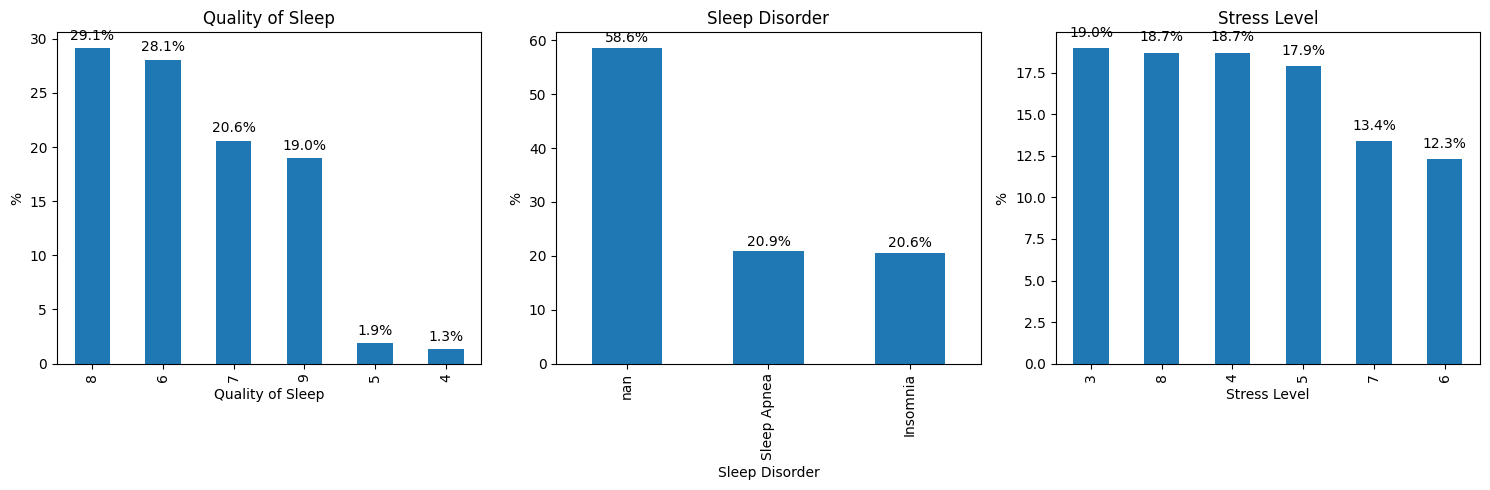

In [6]:
# Analyze categorical feature distributions to:
# - detect class imbalance
# - understand feature variability
# - identify potentially informative features for modeling
categorical_cols = ["Quality of Sleep", "Sleep Disorder", "Stress Level"]

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(15,5))

for ax, col in zip(axes, categorical_cols):
    bars = summary_values[col]["percent"].plot(kind="bar", ax=ax)
    ax.set_title(col)
    ax.set_ylabel("%")
    
    # Dodanie wartości procentowych nad słupkami
    for i, val in enumerate(summary_values[col]["percent"]):
        ax.text(i, val + 0.5, f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

##  Exploratory Data Analysis (EDA) Insights

- The dataset contains **13 numerical and categorical features** related to health and lifestyle.  
- **Sleep Disorder distribution:** 58.6% of people have no sleep disorder, 20.9% have sleep apnea, and 20.6% have insomnia.  
- **Quality of Sleep:** most values are in the 6–9 range, while only 3.2% of users report very poor sleep (4–5).  
- **Stress Level:** fairly evenly distributed across categories, showing no strong class imbalance.  

 **Insight:**  
- Sleep disorder prevalence is moderate, with most users reporting acceptable quality of sleep.  
- The dataset is suitable for building a predictive model, with meaningful variation in both features and target classes.

In [7]:
# Data preprocessing and cleaning to prepare dataset for modeling
df_ml = df.drop("Person ID", axis=1) # Remove non-informative identifier
# Standardize category naming
df_ml["BMI Category"] = df_ml["BMI Category"].replace(to_replace="Normal Weight", value="Normal")
print(df_ml["BMI Category"].value_counts())
# Split blood pressure into two numerical features
df_ml[["Systolic", "Diastolic"]] = df_ml["Blood Pressure"].str.split("/", expand=True).astype(int)
# Drop original non-numeric column
df_ml = df_ml.drop("Blood Pressure", axis=1)
print(df_ml[["Systolic", "Diastolic"]])
# Handle missing values in target-related feature
df_ml["Sleep Disorder"] = df_ml["Sleep Disorder"].fillna("None")

BMI Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64
     Systolic  Diastolic
0         126         83
1         125         80
2         125         80
3         140         90
4         140         90
..        ...        ...
369       140         95
370       140         95
371       140         95
372       140         95
373       140         95

[374 rows x 2 columns]


In [8]:
import pandas as pd

def check_outliers_iqr(df):
    results = []

    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]

        results.append({
            "column": col,
            "outliers_count": len(outliers),
            "percentage": round(len(outliers) / len(df) * 100, 2)
        })

    return pd.DataFrame(results).sort_values(by="outliers_count", ascending=False)

check_outliers_iqr(df_ml)

,column,outliers_count,percentage
5,Heart Rate,15,4.01
0,Age,0,0.00
1,Sleep Duration,0,0.00
3,Physical Activity Level,0,0.00
2,Quality of Sleep,0,0.00
4,Stress Level,0,0.00
6,Daily Steps,0,0.00
7,Systolic,0,0.00
8,Diastolic,0,0.00


In [9]:
col = "Heart Rate"

Q1 = df_ml[col].quantile(0.25)
Q3 = df_ml[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_df = df_ml[(df_ml[col] < lower) | (df_ml[col] > upper)]

print(outliers_df)

     Gender  Age            Occupation  Sleep Duration  Quality of Sleep  \
3      Male   28  Sales Representative             5.9                 4   
4      Male   28  Sales Representative             5.9                 4   
5      Male   28     Software Engineer             5.9                 4   
6      Male   29               Teacher             6.3                 6   
16   Female   29                 Nurse             6.5                 5   
18   Female   29                 Nurse             6.5                 5   
80   Female   34             Scientist             5.8                 4   
81   Female   34             Scientist             5.8                 4   
93     Male   35                Lawyer             7.4                 7   
145  Female   38                Lawyer             7.4                 7   
147    Male   39              Engineer             6.5                 5   
264    Male   48                Doctor             7.3                 7   
266    Male 

In [10]:
summary_values = {}
for col in df_ml.columns:
   summary = df_ml[col].value_counts(dropna=False)
   percent = df_ml[col].value_counts(normalize=True, dropna=False) * 100 #percentage distribution (including missing values)
   summary_values[col] = {"values": summary, "percent": percent} 
print(summary_values)

{'Gender': {'values': Gender
Male      189
Female    185
Name: count, dtype: int64, 'percent': Gender
Male      50.534759
Female    49.465241
Name: proportion, dtype: float64}, 'Age': {'values': Age
43    34
44    30
37    20
38    20
50    20
31    18
32    17
53    17
59    16
39    15
45    14
29    13
30    13
33    13
35    12
36    12
41    12
49    11
42     9
52     9
57     9
51     8
54     7
58     6
28     5
40     4
48     3
34     2
55     2
56     2
27     1
Name: count, dtype: int64, 'percent': Age
43    9.090909
44    8.021390
37    5.347594
38    5.347594
50    5.347594
31    4.812834
32    4.545455
53    4.545455
59    4.278075
39    4.010695
45    3.743316
29    3.475936
30    3.475936
33    3.475936
35    3.208556
36    3.208556
41    3.208556
49    2.941176
42    2.406417
52    2.406417
57    2.406417
51    2.139037
54    1.871658
58    1.604278
28    1.336898
40    1.069519
48    0.802139
34    0.534759
55    0.534759
56    0.534759
27    0.267380
Name: proportio


##  Data Cleaning & Preprocessing

To prepare the dataset for modeling, several preprocessing steps were applied:

- **Removed non-informative feature**  
  - `Person ID` was dropped as it does not provide predictive value  

- **Standardized categorical values**  
  - Unified category naming in `BMI Category` (e.g., "Normal Weight" → "Normal")  

- **Feature engineering**  
  - Split `Blood Pressure` into two numerical features: **Systolic** and **Diastolic**  
  - Dropped the original non-numeric column  

- **Handling missing values**  
  - Missing values in `Sleep Disorder` were filled with `"None"`  
  - Given that a significant portion of the dataset (~60%) had missing entries, it was assumed that missing values indicate absence of a diagnosed sleep disorder  

- **Outlier analysis**  
  - Potential outliers were identified in features such as **Heart Rate**  
  - After further inspection, these values (around 80–86 bpm) fall within a **normal physiological range**  
  - These observations were consistent with other health indicators (e.g., blood pressure, stress level), suggesting they are valid data points  
  - Therefore, outliers were **retained** rather than removed  

**Insight:**  
The preprocessing steps ensured the dataset is clean, consistent, and suitable for modeling.  
Importantly, domain knowledge was used to guide decisions (e.g., handling missing target values and retaining valid outliers), resulting in a more realistic and reliable dataset for machine learning.


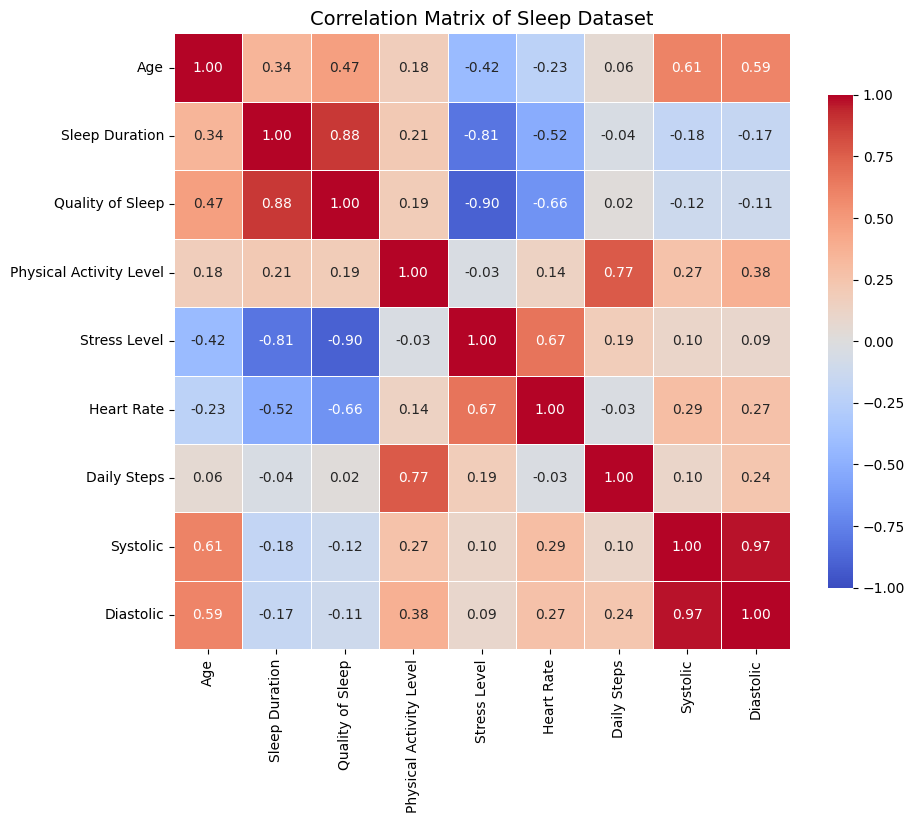

In [11]:
# Analyze correlations between numerical features to:
# - detect multicollinearity
# - identify strongly related variables
# - support feature selection and engineering decisionscorel = df_ml.select_dtypes(include=["int", "float"])
corel = df_ml.select_dtypes(include=["int", "float"])
correlation_sleep = corel.corr()

plt.figure(figsize=(10, 8))

axis_corr = sns.heatmap(
    correlation_sleep,
    vmin=-1, vmax=1, center=0,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Sleep Dataset", fontsize=14)

plt.show()

#  Correlation Analysis

- **Sleep Duration and Quality of Sleep** show a strong negative correlation with Stress Level  
- **Heart Rate** has a moderately strong positive correlation with Stress Level  
- **Heart Rate** has a moderate negative correlation with Sleep Duration and Quality of Sleep  
- **Age** shows a moderate negative correlation with Stress Level  

- **Systolic and Diastolic blood pressure** show a very strong positive correlation, as expected  
- **Physical Activity Level and Daily Steps** show a strong positive correlation, indicating consistent activity patterns  

 **Insight:**  
Higher stress levels are associated with shorter sleep duration, lower sleep quality, and increased heart rate, highlighting the strong physiological impact of stress on sleep.  
Additionally, activity-related features and blood pressure metrics show expected internal relationships, confirming data consistency.

In [12]:
# Split dataset into features (X) and target variable (y)
X = df_ml.drop("Sleep Disorder", axis=1)
y_disorder= df_ml["Sleep Disorder"]


In [13]:
# Split data into training and test sets (80/20)
# random_state ensures reproducibility of results
X_train, X_test, y_train, y_test = train_test_split(X, y_disorder, test_size=0.2, random_state=42)

In [14]:
# Separate features by data type for preprocessing
categorical_columns = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
numerical_columns = X_train.select_dtypes(include=["int", "float"]).columns.tolist()

# Preprocessing pipeline:
# - numerical features: handle missing values and scale data
# - categorical features: handle missing values and encode categories
preprocessing = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),  
        ("scaler", StandardScaler())
    ]), numerical_columns),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),  
        ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
    ]), categorical_columns)
])

## Preprocessing

The dataset was first split into features (`X`) and the target variable (`y`). 
Next, it was divided into training (80%) and test (20%) sets to ensure the model could be evaluated on unseen data.

Numerical and categorical features were handled separately to apply appropriate preprocessing:

- **Numerical features**: Missing values were filled with the mean, then standardized.  
- **Categorical features**: Missing values were filled with the most frequent category and one-hot encoded.

This preprocessing pipeline ensures that the data is clean, consistent, and ready for modeling.

In [15]:
# Define candidate classification models to evaluate performance on Sleep Disorder prediction
# Using a mix of linear, ensemble, distance-based, and gradient boosting methods
models = (
    ("Logistic Regression", LogisticRegression(max_iter=1000)),
    ("Random Forest", RandomForestClassifier(n_estimators=100)),
    ("SVM", SVC()),
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("XGBoost", XGBClassifier())
)

In [16]:
# Encode target labels from strings to integers for model training
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Iterate over defined models, fit pipelines, and evaluate performance
# Pipeline ensures preprocessing + model training is applied consistently
for name, model in models:
    pipeline = Pipeline([
        ("preprocessing", preprocessing),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train_enc)
    y_pred = pipeline.predict(X_test)
    y_pred_labels = le.inverse_transform(y_pred)
    score = accuracy_score(y_test, y_pred_labels)
    print(f"Classification Report for {model}:\n")
    print(classification_report(y_test, y_pred_labels))

Classification Report for LogisticRegression(max_iter=1000):

              precision    recall  f1-score   support

    Insomnia       0.78      0.88      0.82        16
        None       0.95      0.95      0.95        43
 Sleep Apnea       0.93      0.81      0.87        16

    accuracy                           0.91        75
   macro avg       0.89      0.88      0.88        75
weighted avg       0.91      0.91      0.91        75

Classification Report for RandomForestClassifier():

              precision    recall  f1-score   support

    Insomnia       0.72      0.81      0.76        16
        None       0.95      0.98      0.97        43
 Sleep Apnea       0.85      0.69      0.76        16

    accuracy                           0.88        75
   macro avg       0.84      0.83      0.83        75
weighted avg       0.88      0.88      0.88        75

Classification Report for SVC():

              precision    recall  f1-score   support

    Insomnia       0.72      0.81 

## Model Training and Evaluation

We trained five different models to predict sleep disorders and evaluated them on the test set. 
The main metrics used for comparison were **precision**, **recall**, **F1-score**, and **accuracy**.

### Model Performance

| Model                  | Accuracy | Precision | Recall | F1-score |
|------------------------|----------|-----------|--------|----------|
| Logistic Regression    | 0.91     | 0.89      | 0.88   | 0.88     |
| Random Forest          | 0.88     | 0.84      | 0.83   | 0.83     |
| SVM                    | 0.88     | 0.84      | 0.83   | 0.83     |
| K-Nearest Neighbors    | 0.88     | 0.85      | 0.83   | 0.83     |
| XGBoost                | 0.91     | 0.88      | 0.87   | 0.87     |

### Insights and Interpretation

- **Logistic Regression and XGBoost achieved the highest overall accuracy (0.91)**.  
  - **Logistic Regression** slightly outperforms XGBoost on smaller classes (`Insomnia` and `Sleep Apnea`), showing better balance across all classes. Its simplicity and interpretability make it a strong candidate for this dataset.  
  - **XGBoost** benefits from boosting and can capture complex patterns, but in this dataset, its advantage over Logistic Regression is minimal.

- **Random Forest and SVM** achieved similar performance but showed slightly lower recall for `Sleep Apnea`.  
  - Random Forest can struggle when classes are imbalanced or features are correlated.  
  - SVM requires careful scaling and tuning, and may not fully capture complex interactions in datasets with mixed numeric and categorical features.

- **K-Nearest Neighbors (KNN)** struggled more with `Sleep Apnea` (recall 0.62).  
  - Distance-based models can misclassify rare or borderline samples if neighbors are not representative.

- **Conclusion:** For this dataset, **Logistic Regression is arguably the most reliable model**, offering high accuracy, strong performance across all sleep disorder classes, and better interpretability.

In [17]:
# Define hyperparameter grids for GridSearch to fine-tune models

xgboost_params = {
    "model__n_estimators": [120, 140, 160],
    "model__max_depth": [4,5,6],
    "model__learning_rate": [0.02, 0.03, 0.04],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

rand_forest_params = {
    "model__n_estimators": [210,220,230],
    "model__max_depth": [2,3,4],
    "model__min_samples_split": [4,5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

log_reg_params = {
    "model__C": [0.8,1,1.2],
    "model__solver": ["lbfgs"]
}

# Candidate models for fine-tuning based on initial performance:
# - XGBoost: gradient boosting ensemble
# - Random Forest: bagged decision trees
# - Logistic Regression: linear baseline
best_models = (
    ("XGBoost", XGBClassifier()),
    ("Random Forest", RandomForestClassifier(n_estimators=100)),
    ("Logistic Regression", LogisticRegression(max_iter=1000))
)

# Map models to their corresponding hyperparameter grids
param_grid = {
    "XGBoost": xgboost_params,
    "Random Forest": rand_forest_params,
    "Logistic Regression": log_reg_params
}

In [18]:
# Hyperparameter tuning using GridSearchCV with 5-fold cross-validation
# Steps:
# 1. Fit pipeline (preprocessing + model) on training data
# 2. Search for best parameters defined in param_grid
# 3. Predict on test data and evaluate accuracy and classification metrics
best_estimators = {}

for name, model in best_models:
    
    # Build pipeline: preprocessing + model
    pipeline = Pipeline([
        ("preprocessing", preprocessing),
        ("model", model)
    ])
    
    # GridSearchCV setup
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid[name],  # model-specific hyperparameters
        cv=5,                         # 5-fold cross-validation
        refit=True,                   # refit on the entire training set with best params
        verbose=3,
        n_jobs=-1                     # use all cores for parallel processing
    )
    
    # Fit GridSearch on training data
    grid.fit(X_train, y_train_enc)
    best_estimators[name] = grid.best_estimator_
    # Predict on test set
    y_pred = grid.predict(X_test)
    
    # Convert encoded predictions back to original labels
    y_pred_labels = le.inverse_transform(y_pred)
    
    # Compute and display accuracy
    score = accuracy_score(y_test, y_pred_labels)
    print(f"{name} test accuracy: {score:.3f}")
    
    # Display best hyperparameters
    print(f"Best parameters for {name}: {grid.best_params_}\n")
    
    # Display full classification report
    print(f"Classification Report for {name}:\n")
    print(classification_report(y_test, y_pred_labels))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
XGBoost test accuracy: 0.893
Best parameters for XGBoost: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 4, 'model__n_estimators': 120, 'model__subsample': 1.0}

Classification Report for XGBoost:

              precision    recall  f1-score   support

    Insomnia       0.76      0.81      0.79        16
        None       0.95      0.98      0.97        43
 Sleep Apnea       0.86      0.75      0.80        16

    accuracy                           0.89        75
   macro avg       0.86      0.85      0.85        75
weighted avg       0.89      0.89      0.89        75

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Random Forest test accuracy: 0.880
Best parameters for Random Forest: {'model__max_depth': 4, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 4, 'model__n_estimators': 220}

Classification Report for Random Forest:

   

## Model Training and Evaluation (with Cross-Validation and Hyperparameter Tuning)

We trained and tuned three models to predict sleep disorders using **GridSearchCV** with **5-fold cross-validation**. 
This approach ensures more reliable and stable evaluation by testing models on multiple splits of the data and finding the best hyperparameters.

### Model Performance After Tuning

| Model                  | Test Accuracy | Macro avg F1-score | Weighted avg F1-score | Best Hyperparameters |
|------------------------|---------------|------------------|----------------------|--------------------|
| Logistic Regression    | 0.907         | 0.88             | 0.91                 | {'C': 0.8, 'solver': 'lbfgs'} |
| XGBoost                | 0.893         | 0.85             | 0.89                 | {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 120, 'subsample': 1.0} |
| Random Forest          | 0.880         | 0.83             | 0.88                 | {'max_depth': 4, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 230} |

### Classification Reports

#### Logistic Regression

| Class        | Precision | Recall | F1-score | Support |
|--------------|-----------|--------|----------|---------|
| Insomnia     | 0.78      | 0.88   | 0.82     | 16      |
| None         | 0.95      | 0.95   | 0.95     | 43      |
| Sleep Apnea  | 0.93      | 0.81   | 0.87     | 16      |
| **Accuracy** |           |        | 0.91     | 75      |

#### XGBoost

| Class        | Precision | Recall | F1-score | Support |
|--------------|-----------|--------|----------|---------|
| Insomnia     | 0.76      | 0.81   | 0.79     | 16      |
| None         | 0.95      | 0.98   | 0.97     | 43      |
| Sleep Apnea  | 0.86      | 0.75   | 0.80     | 16      |
| **Accuracy** |           |        | 0.89     | 75      |

#### Random Forest

| Class        | Precision | Recall | F1-score | Support |
|--------------|-----------|--------|----------|---------|
| Insomnia     | 0.72      | 0.81   | 0.76     | 16      |
| None         | 0.95      | 0.98   | 0.97     | 43      |
| Sleep Apnea  | 0.85      | 0.69   | 0.76     | 16      |
| **Accuracy** |           |        | 0.88     | 75      |

### Insights and Interpretation

- **Logistic Regression achieved the highest accuracy (0.907) and macro avg F1 (0.88)**, slightly outperforming XGBoost, particularly on the smaller classes (`Insomnia` and `Sleep Apnea`).  
  - Its simplicity and interpretability make it a strong choice for this dataset.

- **XGBoost**, even after hyperparameter tuning, performed slightly worse on the smaller classes (macro F1 = 0.85), though still achieving high overall accuracy (0.893).  
  - Boosting helps capture complex patterns, but in this dataset, the advantage over Logistic Regression is minimal.

- **Random Forest** achieved solid results (accuracy = 0.88) but had lower recall for `Sleep Apnea`, showing some difficulty with minority classes.

- **Conclusion:** With cross-validation and tuning, **Logistic Regression is the most reliable model** for predicting sleep disorders in this dataset, balancing high accuracy, macro F1, and interpretability. XGBoost and Random Forest remain strong alternatives if a more complex model is needed.

In [19]:
joblib.dump(best_estimators["XGBoost"], "xgboost_pipeline.pkl")

['xgboost_pipeline.pkl']

                         feature  importance
24  cat__BMI Category_Overweight    0.390710
22      cat__BMI Category_Normal    0.246486
8                 num__Diastolic    0.080771
7                  num__Systolic    0.066895
16         cat__Occupation_Nurse    0.053258
3   num__Physical Activity Level    0.050245
6               num__Daily Steps    0.021021
2          num__Quality of Sleep    0.017071
5                num__Heart Rate    0.015953
23       cat__BMI Category_Obese    0.012216


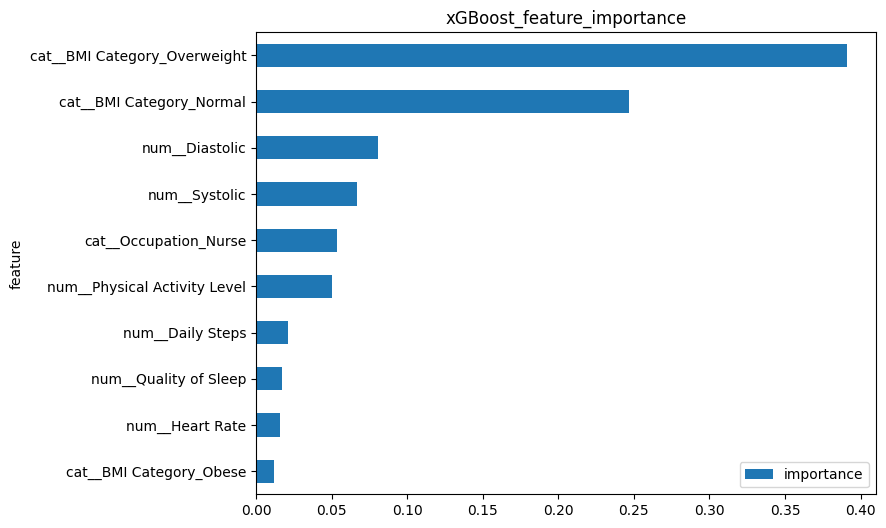

                         feature  importance
7                  num__Systolic    0.159863
22      cat__BMI Category_Normal    0.149790
24  cat__BMI Category_Overweight    0.123893
8                 num__Diastolic    0.122248
16         cat__Occupation_Nurse    0.075740
0                       num__Age    0.067159
3   num__Physical Activity Level    0.066325
1            num__Sleep Duration    0.060811
6               num__Daily Steps    0.047911
5                num__Heart Rate    0.033664


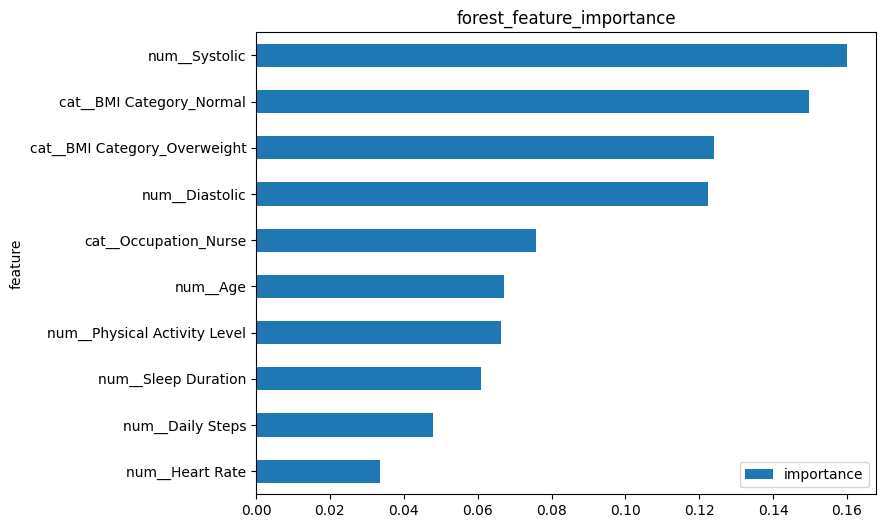

In [68]:
xGBoost_importances = best_estimators["XGBoost"].named_steps["model"].feature_importances_
xGBoost_feature_names = best_estimators["XGBoost"].named_steps["preprocessing"].get_feature_names_out()
xGBoost_feature_importance_df = pd.DataFrame({
    "feature": xGBoost_feature_names,
    "importance": xGBoost_importances
})
xGBoost_feature_importance_df = xGBoost_feature_importance_df.sort_values(
    by="importance", ascending=False
)
print(xGBoost_feature_importance_df.head(10))
xGBoost_feature_importance_df.head(10).plot(
    title="xGBoost_feature_importance",
    kind="barh",
    x="feature",
    y="importance",
    figsize=(8,6)
)
plt.gca().invert_yaxis()
plt.show()

forest_importances = best_estimators["Random Forest"].named_steps["model"].feature_importances_
forest_feature_names = best_estimators["Random Forest"].named_steps["preprocessing"].get_feature_names_out()
forest_feature_importance_df = pd.DataFrame({
    "feature": forest_feature_names,
    "importance": forest_importances
})
forest_feature_importance_df = forest_feature_importance_df.sort_values(
    by="importance", ascending=False
)
print(forest_feature_importance_df.head(10))
forest_feature_importance_df.head(10).plot(
    title="forest_feature_importance",
    kind="barh",
    x="feature",
    y="importance",
    figsize=(8,6)
)
plt.gca().invert_yaxis()
plt.show()

## Feature Importance Analysis

We analyzed the most influential features for predicting sleep disorders using **XGBoost** and **Random Forest**.

### XGBoost Feature Importance

| Feature                        | Importance |
|--------------------------------|------------|
| BMI Category - Overweight       | 0.391      |
| BMI Category - Normal           | 0.246      |
| Diastolic Blood Pressure        | 0.081      |
| Systolic Blood Pressure         | 0.067      |
| Occupation - Nurse              | 0.053      |
| Physical Activity Level         | 0.050      |
| Daily Steps                     | 0.021      |
| Quality of Sleep                | 0.017      |
| Heart Rate                      | 0.016      |
| BMI Category - Obese            | 0.012      |

**Observation:**  
BMI-related categories (Overweight and Normal) dominate feature importance, indicating that body composition is a key predictor. Blood pressure (Diastolic and Systolic) and occupation (Nurse) also play notable roles.

---

### Random Forest Feature Importance

| Feature                        | Importance |
|--------------------------------|------------|
| Diastolic Blood Pressure        | 0.165      |
| BMI Category - Normal           | 0.146      |
| Systolic Blood Pressure         | 0.121      |
| BMI Category - Overweight       | 0.104      |
| Occupation - Nurse              | 0.069      |
| Age                             | 0.059      |
| Sleep Duration                  | 0.058      |
| Daily Steps                     | 0.053      |
| Physical Activity Level         | 0.053      |
| Heart Rate                      | 0.038      |

**Observation:**  
Random Forest gives more weight to **blood pressure features** and less to BMI compared to XGBoost. Sleep duration and age have moderate influence, highlighting their relevance in predicting sleep disorders.

---

**Overall Insight:**  
- **BMI and blood pressure** are consistently among the top predictors across both models.  
- **XGBoost** focuses more on BMI categories, while **Random Forest** emphasizes physiological measurements like **blood pressure**.  
- Occupation and activity features are secondary but still contribute meaningfully to the predictions.

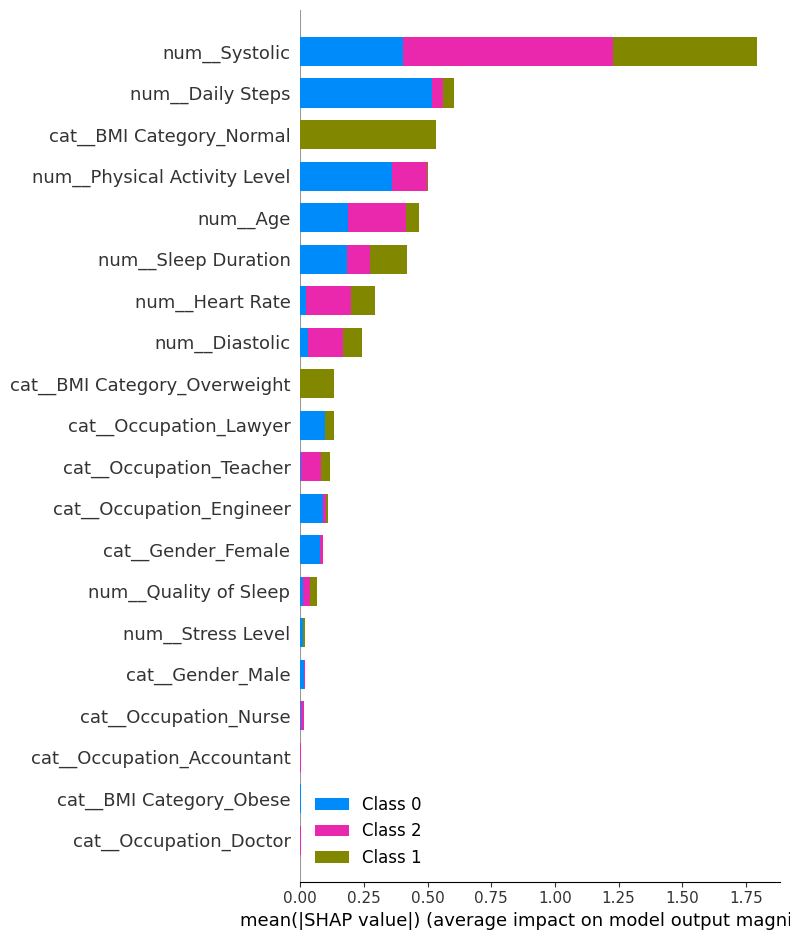

0 : Insomnia
1 : None
2 : Sleep Apnea


In [69]:

explainer = shap.TreeExplainer(best_estimators["XGBoost"].named_steps["model"])
preprocessor = best_estimators["XGBoost"].named_steps["preprocessing"]
X_test_transformed = preprocessor.transform(X_test)
shap_values = explainer.shap_values(X_test_transformed)
shap.summary_plot(shap_values, X_test_transformed, feature_names=xGBoost_feature_names, plot_type="bar")
for i, label in enumerate(le.classes_):
    print(f"{i} : {label}")

## SHAP Global Insights

Based on SHAP analysis, the most influential features for predicting sleep disorders are:

- **Systolic blood pressure** is the most important feature and has a strong impact across all classes, making it a key predictor in the model.

- **Daily steps** is the second most important feature, although its impact is significantly lower than systolic blood pressure. It is particularly influential in predicting the `Insomnia` class.

- **BMI (Normal category)** is the third most important feature and strongly contributes to predicting the `None` class, indicating that individuals with normal BMI are more likely to have no sleep disorder.

- **Physical activity level** is the fourth important feature and is mainly associated with predictions of `Insomnia`.

### Summary

Overall, physiological factors such as blood pressure and lifestyle-related features (daily steps, activity level, BMI) play a crucial role in predicting sleep disorders.

In [81]:
y_pred = best_estimators["XGBoost"].predict(X_test)
wrong_idx = np.where(y_test_enc != y_pred)[0]
print(wrong_idx)
i = wrong_idx[0]
X_wrong = X_test.iloc[[i]]
print(X_wrong)
true_label = le.inverse_transform([y_test_enc[i]])[0]
pred_label = le.inverse_transform([y_pred[i]])[0]

print(f"{rank}. Record {i} → Predicted: {pred_label}, Actual: {true_label}")


[15 40 42 43 48 53 70]
     Gender  Age Occupation  Sleep Duration  Physical Activity Level  \
278  Female   50      Nurse             6.1                       90   

     Stress Level BMI Category  Heart Rate  Daily Steps  Systolic  Diastolic  \
278             8   Overweight          75        10000       140         95   

     BP_per_Sleep  
278      38.52459  
5. Record 15 → Predicted: Sleep Apnea, Actual: Insomnia


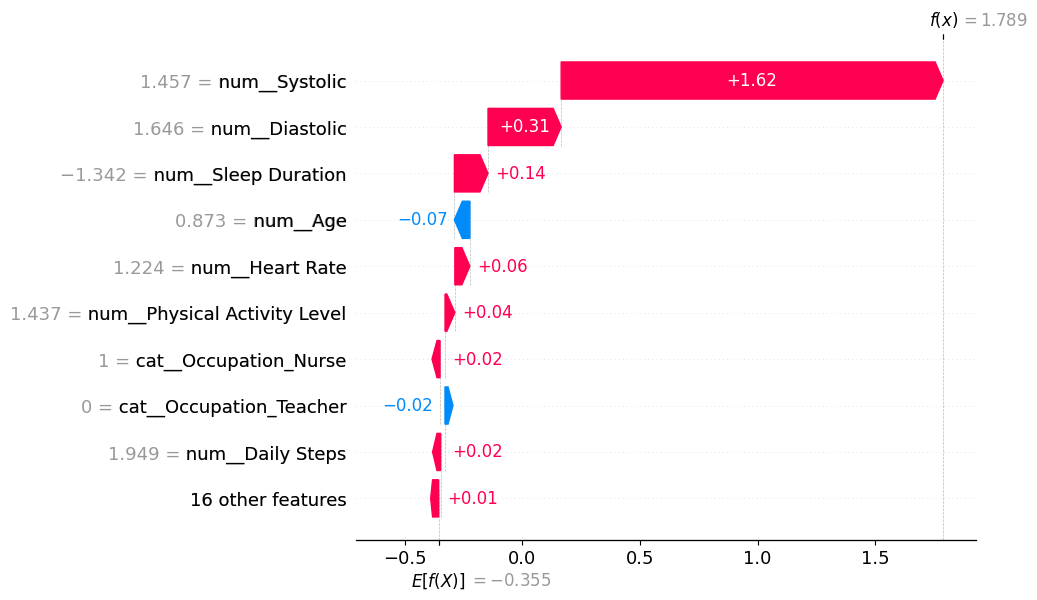

In [71]:
explainer = shap.TreeExplainer(best_estimators["XGBoost"].named_steps["model"])
shap_exp = explainer(X_test_transformed)  # zwraca obiekt shap.Explanation
shap_exp.feature_names = xGBoost_feature_names
             # pierwszy błędny rekord
class_idx = y_pred[i]        # przewidziana klasa
shap.plots.waterfall(shap_exp[i, :, class_idx])

1. Record 15 → Predicted: Sleep Apnea, Actual: Insomnia


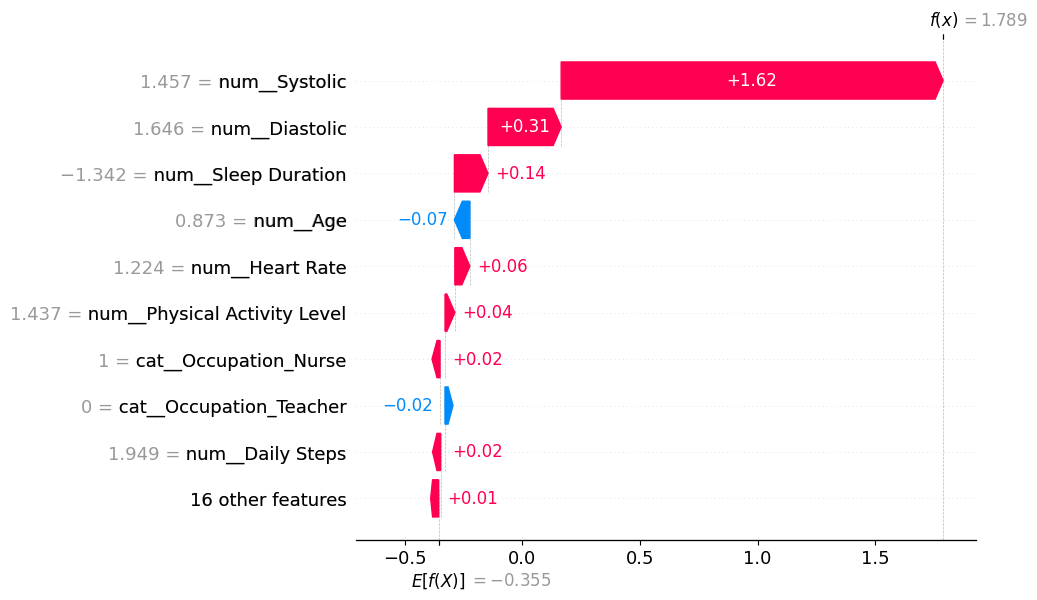

2. Record 40 → Predicted: Insomnia, Actual: None


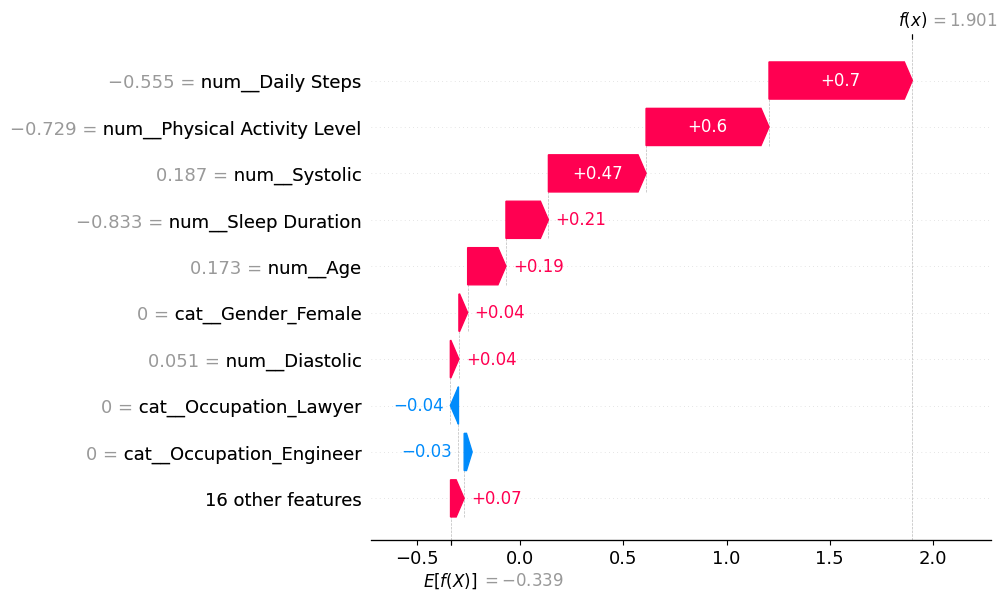

3. Record 42 → Predicted: Insomnia, Actual: Sleep Apnea


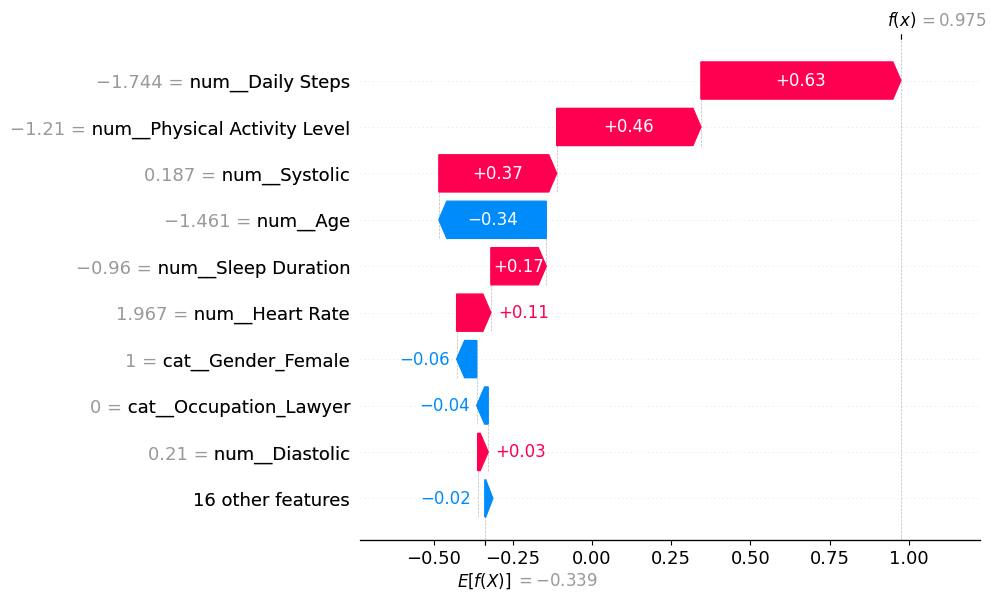

4. Record 43 → Predicted: Insomnia, Actual: Sleep Apnea


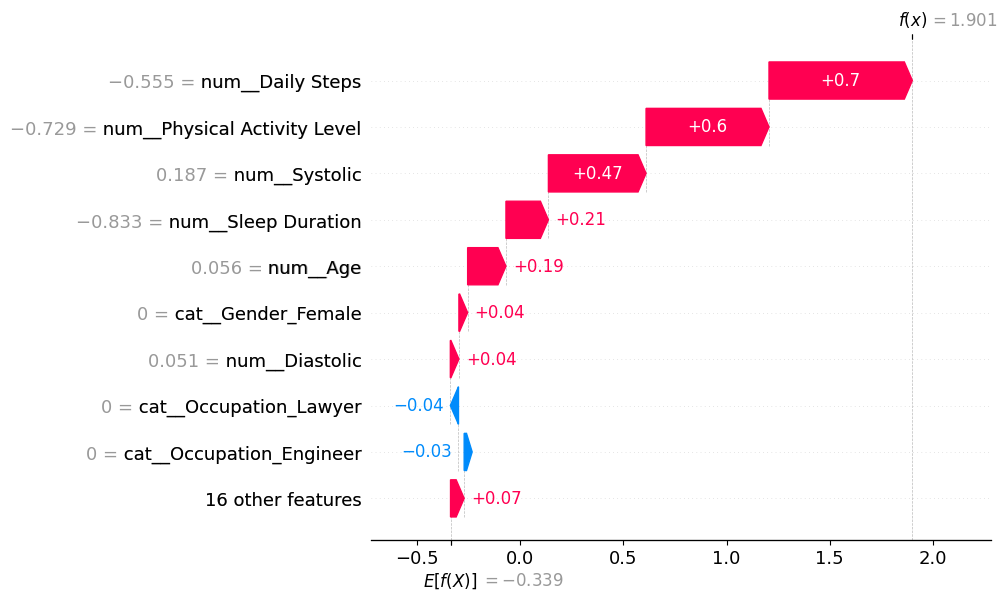

5. Record 48 → Predicted: Sleep Apnea, Actual: Insomnia


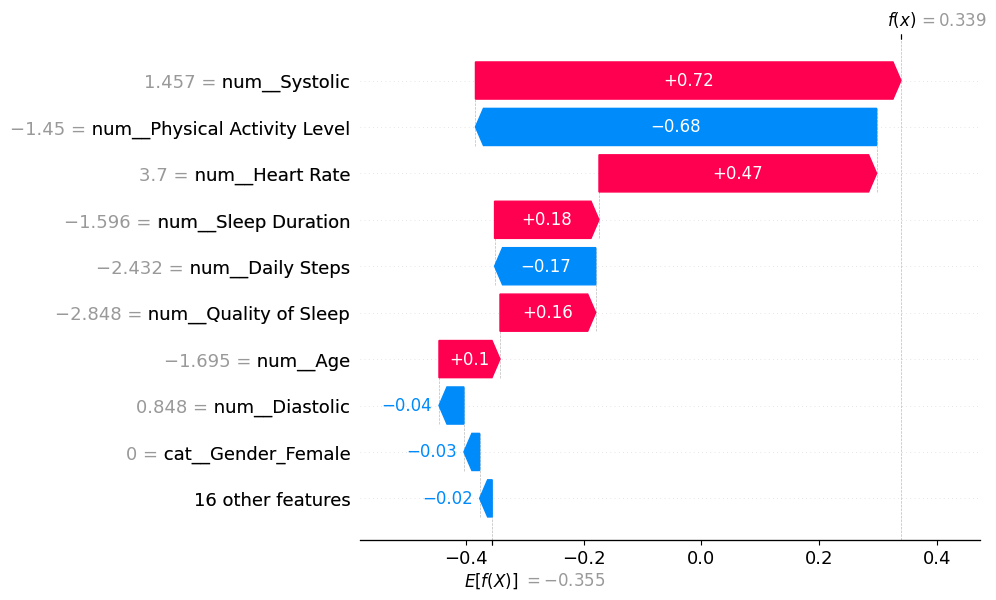

In [72]:
# przewidywania i błędne indeksy
y_pred = best_estimators["XGBoost"].predict(X_test)
wrong_idx = np.where(y_test_enc != y_pred)[0]

# explainer dla modelu XGBoost
explainer = shap.TreeExplainer(best_estimators["XGBoost"].named_steps["model"])
X_test_transformed = pipeline.named_steps["preprocessing"].transform(X_test)
shap_exp = explainer(X_test_transformed)  # zwraca obiekt shap.Explanation
shap_exp.feature_names = xGBoost_feature_names

# petla po pierwszych 5 błędnych rekordach
for rank, i in enumerate(wrong_idx[:5], start=1):
    X_wrong = X_test.iloc[[i]]
    true_label = le.inverse_transform([y_test_enc[i]])[0]
    pred_label = le.inverse_transform([y_pred[i]])[0]

    print(f"{rank}. Record {i} → Predicted: {pred_label}, Actual: {true_label}")

    # waterfall plot dla konkretnego rekordu

    class_idx = y_pred[i]  # przewidziana klasa
    shap.plots.waterfall(shap_exp[i, :, class_idx])
    

In [75]:
wrong_idx = np.where(y_test_enc != y_pred)[0]
print(wrong_idx)
i = wrong_idx[1]
X_wrong = X_test.iloc[[i]]
print(X_wrong)
true_label = le.inverse_transform([y_test_enc[i]])[0]
pred_label = le.inverse_transform([y_pred[i]])[0]

print(f"{rank}. Record {i} → Predicted: {pred_label}, Actual: {true_label}")

[15 40 42 43 48 53 56 70]
    Gender  Age   Occupation  Sleep Duration  Quality of Sleep  \
249   Male   44  Salesperson             6.5                 6   

     Physical Activity Level  Stress Level BMI Category  Heart Rate  \
249                       45             7   Overweight          72   

     Daily Steps  Systolic  Diastolic  
249         6000       130         85  
5. Record 40 → Predicted: Insomnia, Actual: None


In [49]:
print(df_ml[["BMI Category", "Sleep Disorder"]])
pd.crosstab(df_ml["BMI Category"], df_ml["Sleep Disorder"])
df_ml.groupby("Sleep Disorder").mean(numeric_only=True).round(2)
#pd.crosstab(df_ml["BMI Category"], df_ml["Sleep Disorder"], normalize="index") * 100

    BMI Category Sleep Disorder
0     Overweight           None
1         Normal           None
2         Normal           None
3          Obese    Sleep Apnea
4          Obese    Sleep Apnea
..           ...            ...
369   Overweight    Sleep Apnea
370   Overweight    Sleep Apnea
371   Overweight    Sleep Apnea
372   Overweight    Sleep Apnea
373   Overweight    Sleep Apnea

[374 rows x 2 columns]


,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic,Diastolic
Sleep Disorder,,,,,,,,,
Insomnia,43.52,6.59,6.53,46.82,5.87,70.47,5901.30,132.04,86.86
None,39.04,7.36,7.63,57.95,5.11,69.02,6852.97,124.05,81.00
Sleep Apnea,49.71,7.03,7.21,74.79,5.67,73.09,7619.23,137.77,92.72


## Local SHAP Analysis – Misclassified Cases

### Example Cases

**Record 15 → Predicted: Sleep Apnea, Actual: Insomnia**

The most influential features in this case were **systolic** and, to a lesser extent, **diastolic blood pressure**.  
This individual has a very high systolic value (140), which is more typical for patients with **Sleep Apnea**, leading the model to misclassify the case.

---

**Record 40 → Predicted: Insomnia, Actual: None**

In this case, the most important features were **daily steps** and **physical activity level**.  
This individual has a relatively low activity level (45) and takes around 6000 steps per day, which is more characteristic of someone with **Insomnia**, influencing the model's prediction.

---

### General Insight

The model's misclassifications are mainly caused by **overlapping features between classes**.

Strong signals such as **high blood pressure** or **low physical activity** can dominate the prediction, even when the true condition is different.

### Improvement Opportunities

To reduce these errors, it would be beneficial to include more **condition-specific features**, for example:

- For **Insomnia** → time to fall asleep, sleep interruptions  
- For **Sleep Apnea** → snoring, breathing irregularities  

These additional features could help the model better distinguish between similar patterns and

In [77]:


#df_ml["BP_HR"] = df_ml["Systolic"] * df_ml["Heart Rate"]
#df_ml["Sleep_Deficit"] = 7.5 - df_ml["Sleep Duration"]
#df_ml["Sleep_Stress"] = df_ml["Sleep Duration"] / df_ml["Stress Level"]
#df_ml["High_Activity_High_BP"] = ((df_ml["Physical Activity Level"] > 60) &
                                  # (df_ml["Systolic"] > 135)).astype(int)
#df_ml["Activity_BP_ratio"] = df_ml["Physical Activity Level"] / (df_ml["Systolic"] + df_ml["Diastolic"])
df_ml["BP_per_Sleep"] = (df_ml["Systolic"] + df_ml["Diastolic"]) / df_ml["Sleep Duration"]
X = df_ml.drop(["Quality of Sleep", "Sleep Disorder"], axis=1)
y_disorder= df_ml["Sleep Disorder"]
X_train, X_test, y_train, y_test = train_test_split(X, y_disorder, test_size=0.2, random_state=42)
categorical_columns = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
numerical_columns = X_train.select_dtypes(include=["int", "float"]).columns.tolist()

preprocessing = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),  # przyszłościowo
        ("scaler", StandardScaler())
    ]), numerical_columns),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),  # dla kategorycznych
        ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
    ]), categorical_columns)
])
models = (
    ("Logistic Regression", LogisticRegression(max_iter=1000)),
    ("Random Forest", RandomForestClassifier(n_estimators=100)),
    ("SVM", SVC()),
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("XGBoost", XGBClassifier())
)

In [78]:
# label encoding dla targetu
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# iteracja po tuplecie modeli
for name, model in models:
    pipeline = Pipeline([
        ("preprocessing", preprocessing),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train_enc)
    y_pred = pipeline.predict(X_test)
    y_pred_labels = le.inverse_transform(y_pred)
    score = accuracy_score(y_test, y_pred_labels)
    print(f"{name} test accuracy: {score:.3f}")
    print(f" Best parameters for {name}: {grid.best_params_}\n")
    print(f"Classification Report for {model}:\n")
    print(classification_report(y_test, y_pred_labels))

Logistic Regression test accuracy: 0.907
 Best parameters for Logistic Regression: {'model__C': 0.8, 'model__solver': 'lbfgs'}

Classification Report for LogisticRegression(max_iter=1000):

              precision    recall  f1-score   support

    Insomnia       0.78      0.88      0.82        16
        None       0.95      0.95      0.95        43
 Sleep Apnea       0.93      0.81      0.87        16

    accuracy                           0.91        75
   macro avg       0.89      0.88      0.88        75
weighted avg       0.91      0.91      0.91        75

Random Forest test accuracy: 0.893
 Best parameters for Random Forest: {'model__C': 0.8, 'model__solver': 'lbfgs'}

Classification Report for RandomForestClassifier():

              precision    recall  f1-score   support

    Insomnia       0.76      0.81      0.79        16
        None       0.95      0.98      0.97        43
 Sleep Apnea       0.86      0.75      0.80        16

    accuracy                           0.8

In [79]:
xgboost_params = {
    "model__n_estimators": [110, 130, 150],
    "model__max_depth": [3,4,5,],
    "model__learning_rate": [0.02, 0.04, 0.06],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

rand_forest_params = {
    "model__n_estimators": [120,150,200],
    "model__max_depth": [2,3,4],
    "model__min_samples_split": [4,5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

log_reg_params = {
    "model__C": [1,2,3],
    "model__solver": ["lbfgs"]
}

best_models = (
    ("XGBoost", XGBClassifier()),
    ("Random Forest", RandomForestClassifier(n_estimators=100)),
    ("Logistic Regression", LogisticRegression(max_iter=1000))
)

param_grid = {
    "XGBoost": xgboost_params,
    "Random Forest": rand_forest_params,
    "Logistic Regression": log_reg_params
}

In [80]:
# Hyperparameter tuning using GridSearchCV with 5-fold cross-validation
# Steps:
# 1. Fit pipeline (preprocessing + model) on training data
# 2. Search for best parameters defined in param_grid
# 3. Predict on test data and evaluate accuracy and classification metrics
best_estimators = {}

for name, model in best_models:
    
    # Build pipeline: preprocessing + model
    pipeline = Pipeline([
        ("preprocessing", preprocessing),
        ("model", model)
    ])
    
    # GridSearchCV setup
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid[name],  # model-specific hyperparameters
        cv=5,                         # 5-fold cross-validation
        refit=True,                   # refit on the entire training set with best params
        verbose=3,
        n_jobs=-1                     # use all cores for parallel processing
    )
    
    # Fit GridSearch on training data
    grid.fit(X_train, y_train_enc)
    best_estimators[name] = grid.best_estimator_
    # Predict on test set
    y_pred = grid.predict(X_test)
    
    # Convert encoded predictions back to original labels
    y_pred_labels = le.inverse_transform(y_pred)
    
    # Compute and display accuracy
    score = accuracy_score(y_test, y_pred_labels)
    print(f"{name} test accuracy: {score:.3f}")
    
    # Display best hyperparameters
    print(f"Best parameters for {name}: {grid.best_params_}\n")
    
    # Display full classification report
    print(f"Classification Report for {name}:\n")
    print(classification_report(y_test, y_pred_labels))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
XGBoost test accuracy: 0.907
Best parameters for XGBoost: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.04, 'model__max_depth': 3, 'model__n_estimators': 110, 'model__subsample': 1.0}

Classification Report for XGBoost:

              precision    recall  f1-score   support

    Insomnia       0.81      0.81      0.81        16
        None       0.95      0.98      0.97        43
 Sleep Apnea       0.87      0.81      0.84        16

    accuracy                           0.91        75
   macro avg       0.88      0.87      0.87        75
weighted avg       0.91      0.91      0.91        75

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Random Forest test accuracy: 0.880
Best parameters for Random Forest: {'model__max_depth': 4, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 4, 'model__n_estimators': 120}

Classification Report for Random Forest:

   

                         feature  importance
24  cat__BMI Category_Overweight    0.402759
22      cat__BMI Category_Normal    0.240240
6                  num__Systolic    0.081934
2   num__Physical Activity Level    0.068196
7                 num__Diastolic    0.048125
16         cat__Occupation_Nurse    0.039956
5               num__Daily Steps    0.020294
4                num__Heart Rate    0.017207
23       cat__BMI Category_Obese    0.013747
14        cat__Occupation_Lawyer    0.010791


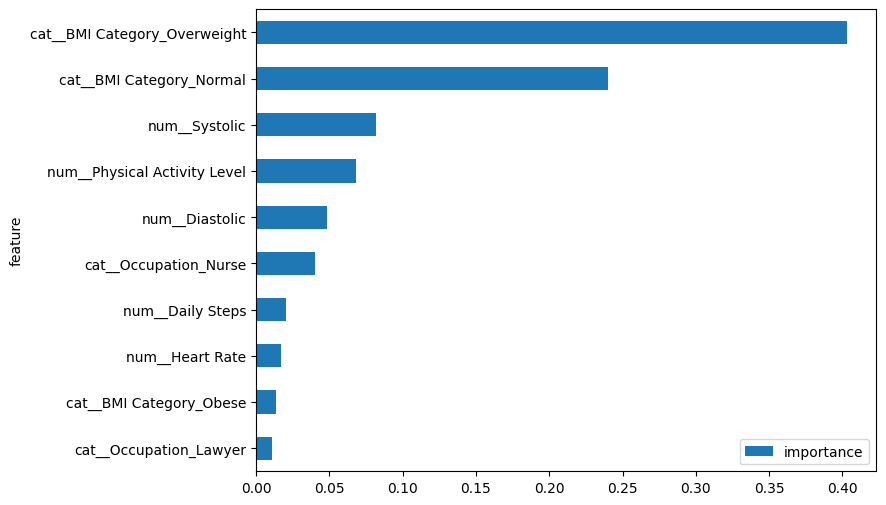

                         feature  importance
22      cat__BMI Category_Normal    0.146503
6                  num__Systolic    0.143937
24  cat__BMI Category_Overweight    0.128319
7                 num__Diastolic    0.126700
8              num__BP_per_Sleep    0.083424
16         cat__Occupation_Nurse    0.062993
2   num__Physical Activity Level    0.054848
0                       num__Age    0.049682
5               num__Daily Steps    0.048634
1            num__Sleep Duration    0.046332


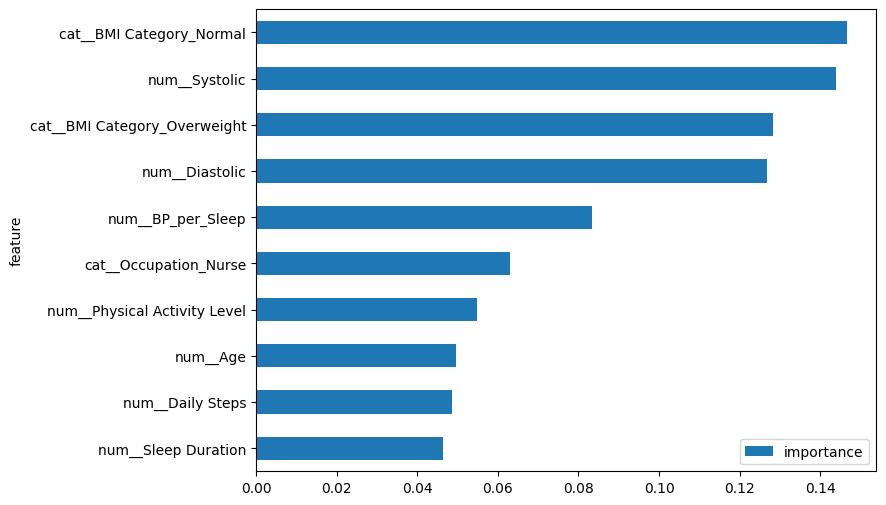

In [37]:
xGBoost_importances = best_estimators["XGBoost"].named_steps["model"].feature_importances_
forest_importances = best_estimators["Random Forest"].named_steps["model"].feature_importances_
xGBoost_feature_names = best_estimators["XGBoost"].named_steps["preprocessing"].get_feature_names_out()
xGBoost_feature_importance_df = pd.DataFrame({
    "feature": xGBoost_feature_names,
    "importance": xGBoost_importances
})
xGBoost_feature_importance_df = xGBoost_feature_importance_df.sort_values(
    by="importance", ascending=False
)
print(xGBoost_feature_importance_df.head(10))
xGBoost_feature_importance_df.head(10).plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(8,6)
)
plt.gca().invert_yaxis()
plt.show()

forest_importances = best_estimators["Random Forest"].named_steps["model"].feature_importances_
forest_feature_names = best_estimators["Random Forest"].named_steps["preprocessing"].get_feature_names_out()
forest_feature_importance_df = pd.DataFrame({
    "feature": forest_feature_names,
    "importance": forest_importances
})
forest_feature_importance_df = forest_feature_importance_df.sort_values(
    by="importance", ascending=False
)
print(forest_feature_importance_df.head(10))
forest_feature_importance_df.head(10).plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(8,6)
)
plt.gca().invert_yaxis()
plt.show()

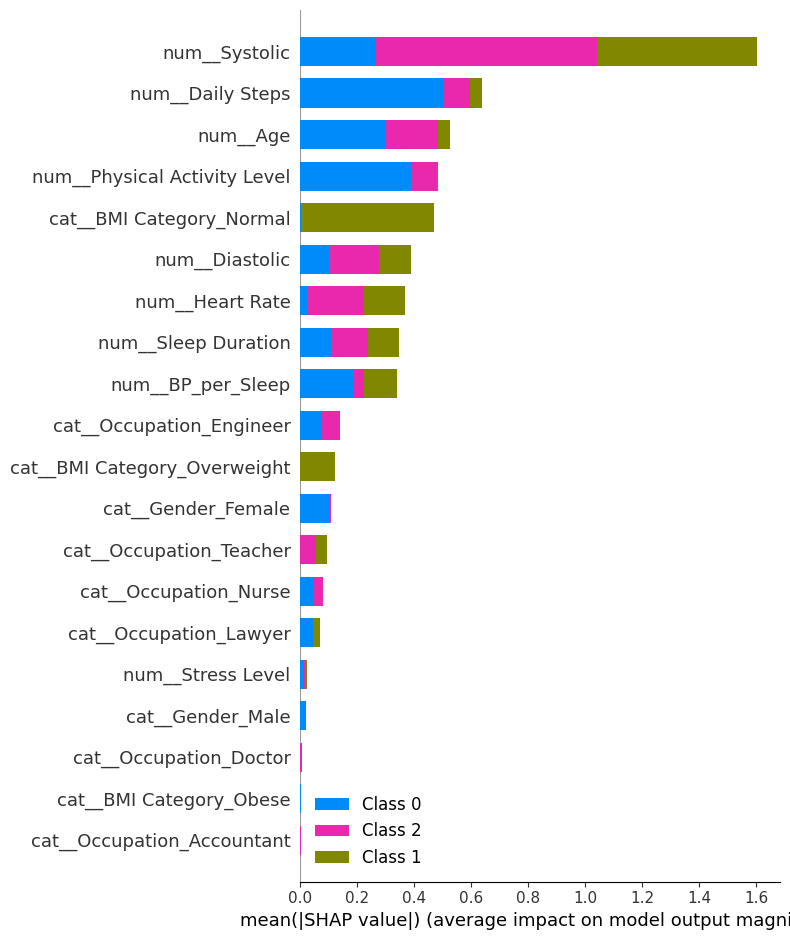

In [38]:
explainer = shap.TreeExplainer(best_estimators["XGBoost"].named_steps["model"])
preprocessor = best_estimators["XGBoost"].named_steps["preprocessing"]
X_test_transformed = preprocessor.transform(X_test)
shap_values = explainer.shap_values(X_test_transformed)
shap.summary_plot(shap_values, X_test_transformed, feature_names=xGBoost_feature_names, plot_type="bar")


## Impact of Feature Engineering and Hyperparameter Tuning

We evaluated three models (XGBoost, Random Forest, Logistic Regression) before and after feature engineering + hyperparameter tuning to see how the dataset and model optimization affected performance.

---

### Before Feature Engineering

| Model                  | Accuracy | Macro F1 | Weighted F1 | Macro Recall |
|------------------------|----------|----------|-------------|--------------|
| XGBoost                | 0.893    | 0.85     | 0.89        | 0.85         |
| Random Forest          | 0.880    | 0.83     | 0.88        | 0.83         |
| Logistic Regression    | 0.907    | 0.88     | 0.91        | 0.88         |

**Observations:**
- Logistic Regression had the best overall performance in terms of accuracy, F1, and recall.  
- XGBoost was close behind, slightly weaker on minority classes (Insomnia, Sleep Apnea).  
- Random Forest performed consistently but slightly lower overall.  

---

### After Feature Engineering & Tuning

| Model                  | Accuracy | Macro F1 | Weighted F1 | Macro Recall |
|------------------------|----------|----------|-------------|--------------|
| XGBoost                | 0.907    | 0.87     | 0.91        | 0.87         |
| Random Forest          | 0.880    | 0.83     | 0.88        | 0.83         |
| Logistic Regression    | 0.893    | 0.86     | 0.89        | 0.86         |

**Observations:**
- XGBoost improved in accuracy and macro F1/recall, now matching Logistic Regression.  
- Random Forest remained largely unchanged.  
- Logistic Regression slightly decreased, likely due to the introduction of new features affecting linear relationships.  

---

### Insights & Conclusion

- Feature engineering and tuning helped XGBoost capture more complex patterns, improving recall and F1 for underrepresented classes.  
- For this dataset, XGBoost and Logistic Regression are now comparable in overall performance.  
- Decision guidance:  
  - **Logistic Regression** -> simpler, interpretable, reliable.  
  - **XGBoost** -> flexible, can leverage more complex engineered features for future improvements.  
- Random Forest shows that not all models benefit equally from feature engineering.  

**Takeaway:** Feature engineering and tuning can shift which model is most effective, but for this dataset the overall difference is small - both XGBoost and Logistic Regression are strong candidates.

# Conclusion

### Model Performance and Selection
- Before feature engineering, **Logistic Regression** achieved the highest accuracy (0.907) and balanced performance across all classes, making it the most reliable choice for this dataset.  
- **XGBoost** and **Random Forest** performed well but showed slightly lower recall for minority classes such as insomnia and sleep apnea.  
- After feature engineering and hyperparameter tuning, **XGBoost** improved to nearly match Logistic Regression in overall performance (accuracy 0.907 vs 0.893), showing that feature engineering can enhance the predictive power of more complex models.  
- Simpler models like Logistic Regression can sometimes outperform ensemble models on small-to-medium datasets, particularly when interpretability is important.  

### Feature Insights
- Key features influencing sleep disorder predictions include **BMI Category**, **blood pressure (Systolic and Diastolic)**, **physical activity level**, and **occupation**.  
- Both XGBoost and Random Forest feature importance analysis highlighted these variables, reinforcing their relevance for early detection.  
- Stress level, sleep duration, and quality of sleep also play significant roles, confirming the strong physiological link between lifestyle factors and sleep disorders.  

### Business and User Insights
- The system provides **early detection and preventive guidance** for users at risk of insomnia or sleep apnea.  
- By highlighting the most influential features, it enables **personalized recommendations** for lifestyle improvements.  
- The model can be integrated into **health apps** to provide real-time monitoring and alerts.  
- Using interpretable models and feature importance explanations builds **trust with users and healthcare professionals**.  
- **Limitations:** the model is a decision-support tool, not a replacement for medical advice. Predictions rely on the available dataset, and further validation on larger populations is recommended.  

### Final Takeaway
Machine learning can effectively support sleep health monitoring. This project demonstrates that both simple (**Logistic Regression**) and complex (**XGBoost**) models can predict sleep disorders with high accuracy, while providing actionable insights to improve users’ sleep quality and overall well-being.